Read in sea ice ensemble statistics monthly files, extract data from these files that lies along a route of interest, calc. RIO values along these same routes, make some plots (largely sandbox for development)

In [ ]:
reset

In [1]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import xarray
import os

In [2]:
years = [ '2025' ]

#months = [ '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
months = [ '06' ]

classes = [ 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6',
           'PC7', 'IAsuper', 'IA', 'IB', 'IC', 
           'NIS' ]
# classes = [ 'IA' ]
    
#     "PC1":  [3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 1, 1, 1],
#     "PC2":  [3, 3, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 0],
#     "PC3":  [3, 3, 3, 3, 2, 2, 2, 2, 2, 1, 0, -1, -1],
#     "PC4":  [3, 3, 3, 3, 2, 2, 2, 2, 1, 0, -1, -2, -2],
#     "PC5":  [3, 3, 3, 3, 2, 2, 1, 1, 0, -1, -2, -2, -2],
#     "PC6":  [3, 2, 2, 2, 2, 1, 1, 0, -1, -2, -3, -3, -3],
#     "PC7":  [3, 2, 2, 2, 1, 1, 0, -1, -2, -3, -3, -3, -3],
#     "IA Super": [3, 2, 2, 2, 2, 1, 0, -1, -2, -3, -4, -4, -4],
#     "IA":   [3, 2, 2, 2, 1, 0, -1, -2, -3, -4, -5, -5, -5],
#     "IB":   [3, 2, 2, 1, 0, -1, -2, -3, -4, -5, -6, -6, -6],
#     "IC":   [3, 2, 1, 0, -1, -2, -3, -4, -5, -6, -7, -8, -8],
#     "Not Ice Strengthened": [3, 1, 0, -1, -2, -3, -4, -5, -6, -7, -8, -8, -8],

In [3]:
# set up some strings for manipulating paths and filenames

pathBase='/lustre/scratch5/sprice//testData/v3.LR.historical_ensembleStats'

os.chdir(pathBase)

prefix='v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.'

readPath = pathBase+prefix

mpassiPrefix = '.mpassi.hist.am.timeSeriesStatsDaily.'

In [4]:
# get lat, lon values for mpas-o cell data
fileIn = '../../mpaso-IcoswISC30E3r5-restart.nc'
ds = xarray.open_dataset(fileIn)

rad2deg = 180.0 / np.pi 

lat_mesh = ds.latCell.values * rad2deg
lon_mesh = ds.lonCell.values * rad2deg

lon_mesh_temp = np.zeros(np.shape(lon_mesh))

# convert long values to same as used in route definitions
for i in np.arange(0,np.size(lon_mesh)):
        if( lon_mesh[i] > 180 ):
            lon_mesh_temp[i] = ( lon_mesh[i] - 360 )
        else:
            lon_mesh_temp[i] = lon_mesh[i]

del lon_mesh
lon_mesh = lon_mesh_temp
del lon_mesh_temp

In [5]:
# This cell active only if working with reduced area (N. of 60 deg) data

# find indices and generate new lat, lon data vectors based on these indices
ind = np.where( lat_mesh >= 60.0)[0]

# redefine lat, lon coord arrays to just contain these values
lat_mesh_temp = lat_mesh[ind]
lon_mesh_temp = lon_mesh[ind]
lon_mesh = lon_mesh_temp
lat_mesh = lat_mesh_temp
del lat_mesh_temp, lon_mesh_temp

In [6]:
#get track data (use old NSR data for development / testing)
fileIn = '../../arctic_route_sections.nc'
ds = xarray.open_dataset(fileIn)

lat_A = ds.lat_A.values
lon_A = ds.lon_A.values
dis_A= ds.dis_A.values

lat_B = ds.lat_B.values
lon_B = ds.lon_B.values
dis_B= ds.dis_B.values

lat_C = ds.lat_C.values
lon_C = ds.lon_C.values
dis_C= ds.dis_C.values

lat_D = ds.lat_D.values
lon_D = ds.lon_D.values
dis_D= ds.dis_D.values

lat_E = ds.lat_E.values
lon_E = ds.lon_E.values
dis_E= ds.dis_E.values

lat_F = ds.lat_F.values
lon_F = ds.lon_F.values
dis_F= ds.dis_F.values

lat_G = ds.lat_G.values
lon_G = ds.lon_G.values
dis_G= ds.dis_G.values

lat_H = ds.lat_H.values
lon_H = ds.lon_H.values
dis_H= ds.dis_H.values

lat_I = ds.lat_I.values
lon_I = ds.lon_I.values
dis_I= ds.dis_I.values

lat_J = ds.lat_J.values
lon_J = ds.lon_J.values
dis_J= ds.dis_J.values

trans_lat=np.hstack((lat_E,lat_J,lat_C,lat_D))  
trans_lon=np.hstack((lon_E,lon_J,lon_C,lon_D))
trans_dist=np.hstack((dis_E,dis_J,dis_C,dis_D))

# trans_lat=np.hstack((lat_A,lat_B,lat_I,lat_H))  
# trans_lon=np.hstack((lon_A,lon_B,lon_I,lon_H))
# trans_dist=np.hstack((dis_A,dis_B,dis_I,dis_H))


In [7]:
# overlay track and mpas-o mesh lat,lon coords
import math
from scipy.spatial import KDTree

# generates a data structure that is queryed to find nearest neighbors given set of lat, lon points
tree = KDTree( list( zip( lon_mesh.flatten(), lat_mesh.flatten() ) ) )

# using 'tree' data structure above, and passed array of lat, lon points from transect of interest,
# generates indices(ind) to nearest (k=)4 mpaso mesh cells and distance(d) between target cell and
# mpaso mesh cells (what units are distances in, degrees?)
kneighbor = 4
d, inds = tree.query( list( zip( trans_lon, trans_lat ) ), k = kneighbor )

# From LAC code: 601 refers to record time dim length (prev. study), which was 50 yrs (2050-2000) x 12 months
# Not needed here (?) ... but leaving for now for ref.

# number = inds[:,0]/601
# #do some magic here to get indices
# ind1=np.zeros((len(number)))
# ind2=np.zeros((len(number)))

# for i in np.arange(0,len(number)):
#     num=number[i]
#     def split_float(num):
#         integer_part = math.trunc(num)
#         decimal_part = num - integer_part
#         return integer_part, decimal_part

#     integer, decimal = split_float(num)
#     ind1[i]=np.int16(integer)
#     ind2[i]=np.int16(601*decimal)


In [8]:
import os

# mapPath = '/lustre/scratch5/sprice/v3.LR.historical_ensembleStats/'
dataPath = '/lustre/scratch5/sprice/testData/v3.LR.historical_ensembleStats/'

os.chdir(dataPath)

print('current path: ', dataPath)

current path:  /lustre/scratch5/sprice/testData/v3.LR.historical_ensembleStats/


In [9]:
import numpy as np

prefix='v3.LR.historical_'

for year in years:
    
    for month in months:

        for cs in classes: 
        
            #fileIn = prefix+year+'-'+month+'-01.nc'
            fileIn = prefix+cs+'_EnsStats'+mpassiPrefix+year+'-'+month+'-01.nc'

            # read in file and relevant vars
            print('reading IN file: ', fileIn)
            dataIn = xarray.open_dataset(fileIn)

            # import RIO value for this ice class 'cs'
            RIOMedian = dataIn.timeDaily_avg_RIO_ensembleMedian.values
            RIO5th = dataIn.timeDaily_avg_RIO_ensemble5th.values
            RIO95th = dataIn.timeDaily_avg_RIO_ensemble95th.values

            ndays = np.size( RIOMedian, axis=0 )     # production: loop over days
#             ndays = np.arange(15,16)                     # debug: use single day
            ncells = np.size( RIOMedian, axis=1 )

            # storage arrays for RIO values along transect of interest
            RIOAlongMed = np.zeros((ndays,len(trans_dist)))
            RIOAlong5th = np.zeros((ndays,len(trans_dist)))
            RIOAlong95th = np.zeros((ndays,len(trans_dist)))
    
            for day in np.arange(0,ndays):

                print('calculating RIO information for year, month, day, vessel: ', year, month, day, cs)

                # Use indices from tree query above to extract and calculate RIO value at
                # points along route of interest.
                    
                for transPoint in np.arange(0,np.size(trans_dist)):

                    # calc. average median RIO (over neighboring cells) at transect point 
                    RIOInMedian = np.mean( RIOMedian[day,inds[transPoint,0:kneighbor]] )
                    RIOAlongMed[day,transPoint]=RIOInMedian

                    # calc. average RIO 5th percentile (over neighboring cells) at transect point 
                    RIOIn5th = np.mean( RIO5th[day,inds[transPoint,0:kneighbor]] )
                    RIOAlong5th[day,transPoint]=RIOIn5th

                    # calc. average RIO 95th percentile conc. (over neighboring cells) at transect point 
                    RIOIn95th = np.mean( RIO95th[day,inds[transPoint,0:kneighbor]] )
                    RIOAlong95th[day,transPoint]=RIOIn95th
                    
            # write along-route RIO out to individual .nc file for this vessel type, all days in month                    
            times = np.arange(1,ndays+1)
            cells = np.arange(1,len(trans_dist)+1)      ## !!! This needs to be cumulative distance eventually !!!
            points = {'Time': times, 'points': cells}
            dims = ('Time', 'nPoints')

            # write along-route RIO out to individual .nc file for this vessel type, all days in month                    
            days = np.arange(1,ndays+1)
            points = np.arange(1,len(trans_dist)+1)      ## !!! This needs to be cumulative distance eventually !!!
            coords1 = {'day': days, 'point': points}
            coords2 = {'point': points}
            dims1 = ('day', 'point')
            dims2 = ('point')

            timeDaily_avg_RIO_ensembleMedian_along = xarray.DataArray( data=RIOAlongMed,
                coords=coords1, dims=dims1, name='timeDaily_avg_RIO_ensembleMedian_along')
            timeDaily_avg_RIO_ensemble5th_along = xarray.DataArray(data=RIOAlong5th,
                coords=coords1, dims=dims1, name='timeDaily_avg_RIO_ensemble5th_along')
            timeDaily_avg_RIO_ensemble95th_along = xarray.DataArray(data=RIOAlong95th,
                coords=coords1, dims=dims1, name='timeDaily_avg_RIO_ensemble95th_along')
            lat_along = xarray.DataArray(data=trans_lat, 
                coords=coords2, dims=dims2, name='lat_along_transect')
            lon_along = xarray.DataArray(data=trans_lon, 
                coords=coords2, dims=dims2, name='lon_along_transect')

            dataOut = xarray.Dataset({
                'timeDaily_avg_RIO_ensembleMedian_along':timeDaily_avg_RIO_ensembleMedian_along,
                'timeDaily_avg_RIO_ensemble5th_along':timeDaily_avg_RIO_ensemble5th_along,
                'timeDaily_avg_RIO_ensemble95th_along':timeDaily_avg_RIO_ensemble95th_along,
                'lat_along_transect':lat_along,
                'lon_along_transect':lon_along,
                })

            writePath = '/lustre/scratch5/sprice/testData/v3.LR.historical_ensembleStats/RIO_Along_Route/'
            if not os.path.exists(writePath):
                os.makedirs(writePath)
                print(f"Directory '{writePath}' created.")
            else:
                print(f"Directory '{writePath}' already exists.")
            os.chdir(dataPath)

            fileOut = writePath+'/'+prefix+cs+'_EnsStatsAlongRoute'+mpassiPrefix+year+'-'+month+'-01.nc'
            print('writing OUT file: ', fileOut)
            dataOut.to_netcdf(fileOut)


reading IN file:  v3.LR.historical_PC1_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
calculating RIO information for year, month, day, vessel:  2025 06 0 PC1
calculating RIO information for year, month, day, vessel:  2025 06 1 PC1
calculating RIO information for year, month, day, vessel:  2025 06 2 PC1
calculating RIO information for year, month, day, vessel:  2025 06 3 PC1
calculating RIO information for year, month, day, vessel:  2025 06 4 PC1
calculating RIO information for year, month, day, vessel:  2025 06 5 PC1
calculating RIO information for year, month, day, vessel:  2025 06 6 PC1
calculating RIO information for year, month, day, vessel:  2025 06 7 PC1
calculating RIO information for year, month, day, vessel:  2025 06 8 PC1
calculating RIO information for year, month, day, vessel:  2025 06 9 PC1
calculating RIO information for year, month, day, vessel:  2025 06 10 PC1
calculating RIO information for year, month, day, vessel:  2025 06 11 PC1
calculating RIO informat

calculating RIO information for year, month, day, vessel:  2025 06 5 PC4
calculating RIO information for year, month, day, vessel:  2025 06 6 PC4
calculating RIO information for year, month, day, vessel:  2025 06 7 PC4
calculating RIO information for year, month, day, vessel:  2025 06 8 PC4
calculating RIO information for year, month, day, vessel:  2025 06 9 PC4
calculating RIO information for year, month, day, vessel:  2025 06 10 PC4
calculating RIO information for year, month, day, vessel:  2025 06 11 PC4
calculating RIO information for year, month, day, vessel:  2025 06 12 PC4
calculating RIO information for year, month, day, vessel:  2025 06 13 PC4
calculating RIO information for year, month, day, vessel:  2025 06 14 PC4
calculating RIO information for year, month, day, vessel:  2025 06 15 PC4
calculating RIO information for year, month, day, vessel:  2025 06 16 PC4
calculating RIO information for year, month, day, vessel:  2025 06 17 PC4
calculating RIO information for year, month

calculating RIO information for year, month, day, vessel:  2025 06 12 PC7
calculating RIO information for year, month, day, vessel:  2025 06 13 PC7
calculating RIO information for year, month, day, vessel:  2025 06 14 PC7
calculating RIO information for year, month, day, vessel:  2025 06 15 PC7
calculating RIO information for year, month, day, vessel:  2025 06 16 PC7
calculating RIO information for year, month, day, vessel:  2025 06 17 PC7
calculating RIO information for year, month, day, vessel:  2025 06 18 PC7
calculating RIO information for year, month, day, vessel:  2025 06 19 PC7
calculating RIO information for year, month, day, vessel:  2025 06 20 PC7
calculating RIO information for year, month, day, vessel:  2025 06 21 PC7
calculating RIO information for year, month, day, vessel:  2025 06 22 PC7
calculating RIO information for year, month, day, vessel:  2025 06 23 PC7
calculating RIO information for year, month, day, vessel:  2025 06 24 PC7
calculating RIO information for year, 

calculating RIO information for year, month, day, vessel:  2025 06 16 IB
calculating RIO information for year, month, day, vessel:  2025 06 17 IB
calculating RIO information for year, month, day, vessel:  2025 06 18 IB
calculating RIO information for year, month, day, vessel:  2025 06 19 IB
calculating RIO information for year, month, day, vessel:  2025 06 20 IB
calculating RIO information for year, month, day, vessel:  2025 06 21 IB
calculating RIO information for year, month, day, vessel:  2025 06 22 IB
calculating RIO information for year, month, day, vessel:  2025 06 23 IB
calculating RIO information for year, month, day, vessel:  2025 06 24 IB
calculating RIO information for year, month, day, vessel:  2025 06 25 IB
calculating RIO information for year, month, day, vessel:  2025 06 26 IB
calculating RIO information for year, month, day, vessel:  2025 06 27 IB
calculating RIO information for year, month, day, vessel:  2025 06 28 IB
calculating RIO information for year, month, day, v

In [ ]:
import os

mapPath = '/lustre/scratch5/sprice/maps'
os.chdir(mapPath)

print('current path: ', mapPath)

In [ ]:
# insert figure here to overlay transect points w/ NN MPAS-SI mesh points

import os
from __future__ import absolute_import, division, print_function, \
    unicode_literals
import xarray as xr
import numpy as np
import numpy.ma as ma
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as cols
from matplotlib.pyplot import cm
from matplotlib.colors import from_levels_and_colors
from matplotlib.colors import BoundaryNorm
import matplotlib.path as mpath
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import cmocean
import shapely.geometry

from geometric_features.feature_collection import read_feature_collection
from common_functions import add_land_lakes_coastline


def _add_bbox(ax, bbox):
    # This plots parallel and meridian arcs using the 'bbox' information 
    # effectively making that the map boundary
    myProj = ccrs.PlateCarree()
    [ax_hdl] = ax.plot([bbox[0], bbox[1], bbox[1], bbox[0], bbox[0]],
                       [bbox[2], bbox[2], bbox[3], bbox[3], bbox[2]],
                       color='black', linewidth=0.5, marker='none',
                       transform=myProj)
    # Get the `Path` of the plot
    tx_path = ax_hdl._get_transformed_path()
    path_in_data_coords, _ = tx_path.get_transformed_path_and_affine()
    # Use the path's vertices to create a polygon
    polygon = mpath.Path(path_in_data_coords.vertices)
    ax.set_boundary(polygon)

bathyfile = './BedMachineAntarctica_v3_and_GEBCO_2023_0.0125_degree_20230831.nc'
featurefile = './arctic_regions_detailed.geojson'
transectfile = None
    
figdir = './'

# clevels = [10, 50, 100, 150, 200, 400, 600, 800, 1000, 1200, 1400, 1800, 2200, 2600, 3000, 3500]
clevels = np.arange(0,1.0)
# clevels = np.arange(0.001,3,0.2)

# colormap = plt.get_cmap(cmocean.cm.deep)
colormap = plt.get_cmap(cmocean.cm.tempo)
# colorIndices = np.int_(np.linspace(0, 255, num=len(clevels)+1, endpoint=True))
# underColor = colormap(colorIndices[0])
# overColor = colormap(colorIndices[-1])
# colorIndices = colorIndices[1:-1]
# colormap = cols.ListedColormap(colormap(colorIndices))
# colormap.set_under(underColor)
# colormap.set_over(overColor)
# cnorm = mpl.colors.BoundaryNorm(clevels, colormap.N)

#ds = xr.open_dataset(bathyfile)

# subsample = 4
# subsample = 1000

# start = float(ds.lon.isel(lon=0).values)   # or ds.lon.values[0]
# stop  = float(ds.lon.isel(lon=-1).values)  # or ds.lon.values[-1]
# n     = int(ds.sizes["lon"] / subsample)   # more robust than ds.dims["lon"]

# new_lat = np.linspace( start, stop, n, endpoint=True)
# new_lon = np.linspace( start, stop, n, endpoint=True)

# bathymetry = -ds.bathymetry.interp(lon=new_lon, lat=new_lat)

# Read in features
features = read_feature_collection(featurefile)
if transectfile is not None:
    transectfeatures = read_feature_collection(transectfile)
#print(dir(features))
#featureNames = [fc['properties']['name'] for fc in features.features]
#print(featureNames)

#featuresToPlot = ['Barents Sea', 'Kara Sea', 'Laptev Sea', 'East Siberian Sea', 'Chukchi Sea', 'Canada Basin', 'Canadian Archipelago', 'Eurasian Basin', 'Makarov Basin']
featuresToPlot = []
colors = ['#2166ac', '#d6604d', '#01665e', '#92c5de', '#b2182b', '#80cdc1', '#a6dba0', '#9970ab', '#ffffbf', '#d6604d', '#2166ac']
color_names = ['dark blue', 'light red', 'dark green', 'light blue', 'dark red', 'aqua', 'light green', 'purple', 'lemon', 'light red', 'dark blue']

#featuresToPlot = ['Barents Sea', 'Kara Sea', 'Laptev Sea', 'East Siberian Sea', 'Chukchi Sea', 'Canada Basin', 'Canadian Archipelago']
##featuresToPlot = ['Barents Sea', 'Kara Sea', 'Laptev Sea', 'East Siberian Sea', 'Chukchi Sea', 'Beaufort Gyre', 'Beaufort Gyre Shelf', 'Canadian Archipelago']
#colors = ['#2166ac', '#d6604d', '#01665e', '#92c5de', '#b2182b', '#80cdc1', '#a6dba0', '#9970ab', '#ffffbf']
#color_names = ['dark blue', 'light red', 'dark green', 'light blue', 'dark red', 'aqua', 'light green', 'purple', 'lemon']
#featuresToPlot = ['Norwegian Sea', 'Greenland Sea', 'Kara Sea', 'Eurasian Basin']
#featuresToPlot = ['Barents Sea']
#colors = ['#2166ac', '#d6604d', '#01665e', '#92c5de']
#color_names = ['dark blue', 'light red', 'dark green', 'light blue']
#color_names = ['dark blue']
#transectsToPlot = ['Iceland-Faroe-Scotland']

# The lat-lon proj
noProj = ccrs.PlateCarree()

# The projection of the map
mapProj = ccrs.NorthPolarStereo(central_longitude=0)

figsize = [20, 20]
figdpi = 300

#extent = [-180, 180, 63, 90] # Arctic Ocean
#extent = [-50, 50, 58, 80] # Nordic Seas
extent = [-180, 180, 65, 90] # NSR
#extent = [0, 120, 70, 80] # NSR (reduced)

plt.figure(figsize=figsize, dpi=figdpi)
ax = plt.axes(projection=mapProj)
add_land_lakes_coastline(ax)
ax.set_extent(extent, crs=noProj)
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, color='w', linestyle=':', zorder=6)

## contour background bathymetry
# #log_norm = cols.LogNorm(vmin=np.min(bathymetry), vmax=np.max(bathymetry))
# log_norm = cols.LogNorm(vmin=10, vmax=3500)
# #cf = ax.pcolormesh(new_lon, new_lat, bathymetry, cmap=colormap, vmin=0, vmax=2500, transform=noProj)
# cf = ax.pcolormesh(new_lon, new_lat, bathymetry, cmap=colormap, transform=noProj, norm=log_norm)
# cbar = plt.colorbar(cf, ticks=clevels, boundaries=clevels, extend='both', shrink=0.4, pad=0.03, orientation='vertical')
# cbar.ax.tick_params(labelsize=14, labelcolor='black')
# cbar.set_label('[m]', fontsize=16)

# ## contour other, non-gridded field
# cf = ax.tricontourf(lon_mesh, lat_mesh, iceAreaMedian[ndays,:].flatten(), cmap=colormap, transform=noProj )
# cbar = plt.colorbar(cf)
# # cbar = plt.colorbar(cf, ticks=clevels, boundaries=clevels, extend='both', shrink=0.4, pad=0.03, orientation='vertical')
# # cbar.ax.tick_params(labelsize=14, labelcolor='black')
# # cbar.set_label('[m]', fontsize=16)

fcIndex = 0
for fcname in featuresToPlot:
    for fc in features.features:
        if fc['properties']['name']==fcname:
            color = colors[fcIndex]
            geomType = fc['geometry']['type']
            shape = shapely.geometry.shape(fc['geometry'])
            props = {'linewidth': 2.0, 'edgecolor': color, 'alpha': 0.5, 'facecolor': color}
            ax.add_geometries((shape,), crs=noProj, **props)
            fcIndex = fcIndex+1
            
# plot transect being analyzed
for transPoint in np.arange(0,np.size(trans_dist)):
     ax.plot(trans_lon[transPoint], trans_lat[transPoint], marker='.', markersize=3, color='red', transform=noProj)

# plot location of mpas-o mesh points that are sampled and interpolated to transect
for transPoint in np.arange(0,np.size(trans_dist)):
    for i in np.arange(1,np.size(inds, axis=1)):
        
        ax.plot(lon_mesh[inds[transPoint,i]], lat_mesh[inds[transPoint,i]], 
#                 marker='H', markersize=10, markerfacecolor='none', 
                marker='.', markersize=0.5, markerfacecolor='none', 
                color='black', transform=noProj)


plt.show()
# plt.savefig(f'{figdir}/ArcticSeaRegions.png', bbox_inches='tight')
# plt.close()

In [15]:
cs

'NIS'

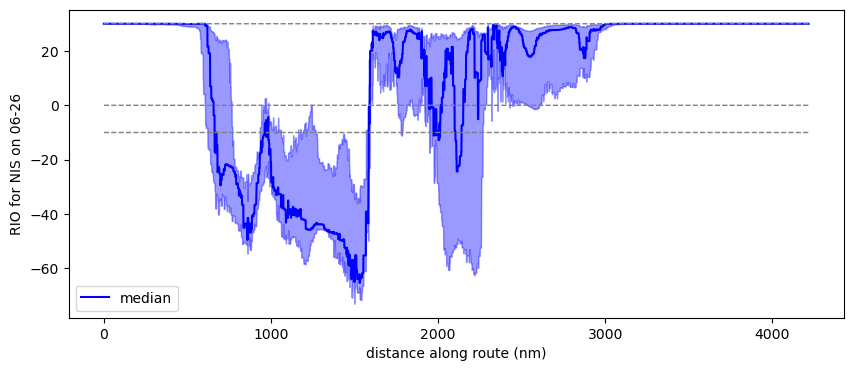

In [52]:
# plot median RIO and 5th/95th percentiles along route for specific vessel type and specific day / month
plt.figure(figsize=(10, 4))
plt.clf()

plt.plot( np.arange(0,np.size(trans_dist)), RIOAlongMed[15,:], 'b-', label='median' )
plt.fill_between(np.arange(0,np.size(trans_dist)), RIOAlong5th[15,:], RIOAlong95th[15,:], color='blue', alpha=0.4)

plt.xlabel( 'distance along route (nm)')
plt.ylabel(f'RIO for {cs} on {month}-{day}')
plt.legend()
plt.plot( np.arange(0,np.size(trans_dist)), 30*np.ones(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )
plt.plot( np.arange(0,np.size(trans_dist)), np.zeros(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )
plt.plot( np.arange(0,np.size(trans_dist)), -10*np.ones(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )

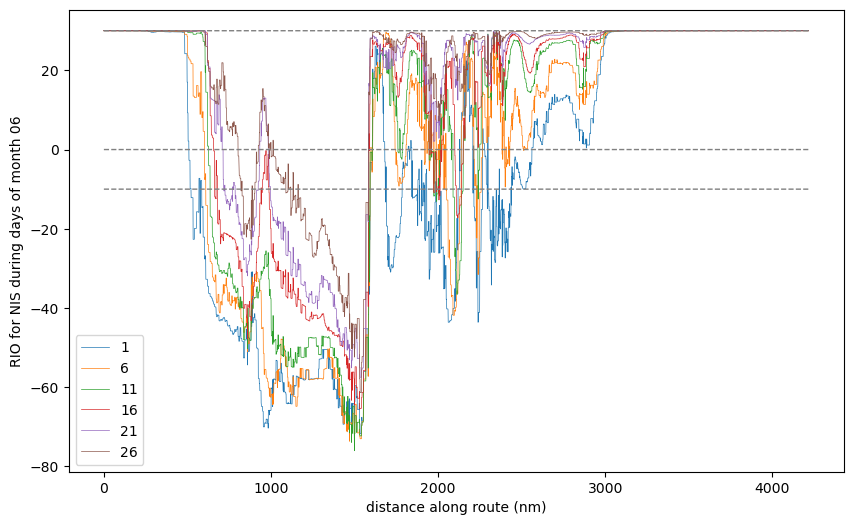

In [53]:
# plot median RIO along route for specific vessel type as function of day of month

plt.figure(figsize=(10, 6))
plt.clf()

for day in np.arange(1,ndays,5):
    plt.plot( np.arange(0,np.size(trans_dist)), RIOAlongMed[day,:], '-', linewidth=0.5, label=day )

plt.xlabel( 'distance along route (nm)')
plt.ylabel(f'RIO for {cs} during days of month {month}')
plt.legend()
plt.plot( np.arange(0,np.size(trans_dist)), 30*np.ones(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )
plt.plot( np.arange(0,np.size(trans_dist)), np.zeros(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )
plt.plot( np.arange(0,np.size(trans_dist)), -10*np.ones(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )

current path:  /lustre/scratch5/sprice/testData/v3.LR.historical_ensembleStats/RIO_Along_Route/
reading IN file:  v3.LR.historical_PC1_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_PC2_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_PC3_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_PC4_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_PC5_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_PC6_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_PC7_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_IAsuper_EnsStatsAlongRoute.mpassi.hist.am.timeSeriesStatsDaily.2025-06-01.nc
reading IN file:  v3.LR.historical_I

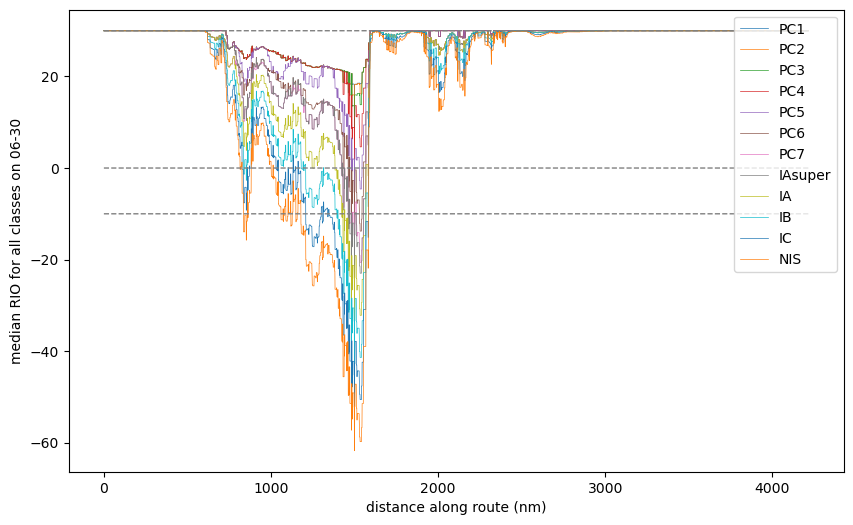

In [58]:
# plot median RIO along route as a function of vessle type (for specific day / month)

import os

RIOpath = writePath
os.chdir(RIOpath)
print('current path: ', RIOpath)

day = 30
month = '06'

plt.figure(figsize=(10, 6))
plt.clf()

for cs in classes: 
        
    fileIn = prefix+cs+'_EnsStatsAlongRoute'+mpassiPrefix+year+'-'+month+'-01.nc'

    # read in file and relevant vars
    print('reading IN file: ', fileIn)
    dataIn = xarray.open_dataset(fileIn)
    
    plotData = dataIn.timeDaily_avg_RIO_ensembleMedian_along[day-1]
    
    plt.plot( np.arange(0,np.size(trans_dist)), plotData, '-', linewidth=0.5, label=cs )

    
plt.xlabel( 'distance along route (nm)')
plt.ylabel( f'median RIO for all classes on {month}-{day}' )
plt.legend(loc='lower right')
plt.plot( np.arange(0,np.size(trans_dist)), 30*np.ones(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )
plt.plot( np.arange(0,np.size(trans_dist)), np.zeros(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )
plt.plot( np.arange(0,np.size(trans_dist)), -10*np.ones(np.size(trans_dist)), color='grey', linestyle='--', linewidth=1.0 )
